# Projeto de predição de estudos

1. Importar bibliotecas

In [ ]:
pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Importar arquivo csv

In [ ]:
df = pd.read_csv('student_habits_performance.csv')

In [ ]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


3. Heat map - quais informações qualitativas mais influenciam

In [ ]:
# Tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

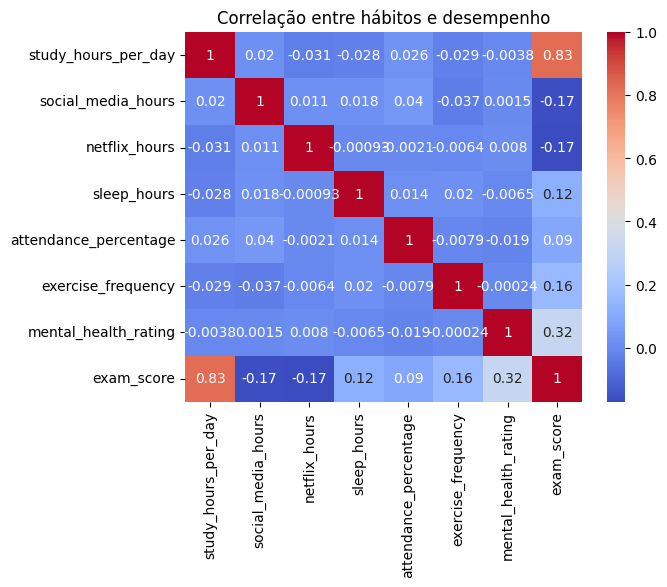

In [ ]:
# Colunas numericas
cols = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "sleep_hours",
    "attendance_percentage",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score",
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre hábitos e desempenho")
plt.show()

Text(0.5, 1.0, 'Correlação entre horas de estudo e nota do exame')

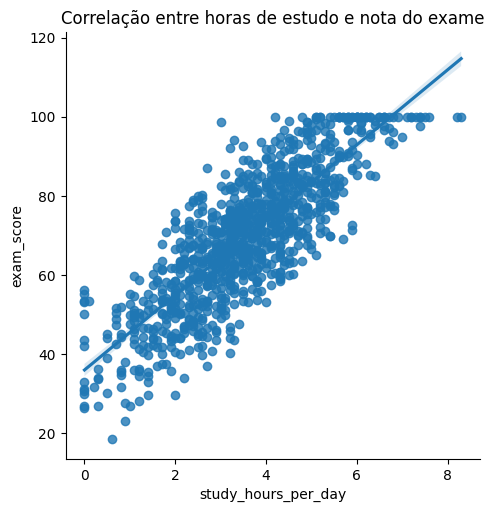

In [ ]:
# Grafico de dispersao com linha de regressao
sns.lmplot(data=df, x="study_hours_per_day", y="exam_score")
plt.title("Correlação entre horas de estudo e nota do exame")

In [ ]:
# Quem estuda > 5 x  < 2

filtro_estudo_alto = df["study_hours_per_day"] > 4
filtro_estudo_baixo = df["study_hours_per_day"] < 2

grupo_estudo_alto = df[filtro_estudo_alto]["exam_score"]
grupo_estudo_baixo = df[filtro_estudo_baixo]["exam_score"]

print("Médias de >4h: ", grupo_estudo_alto.mean())
print("Médias de <2h: ", grupo_estudo_baixo.mean())

Médias de >4h:  83.94630136986302
Médias de <2h:  45.56390977443609


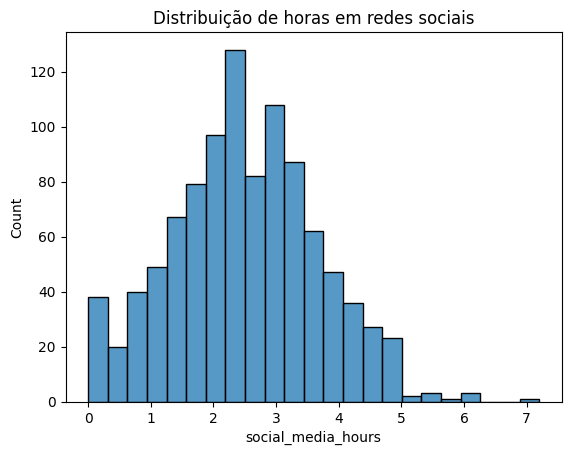

In [ ]:
# Distribuição geral redes sociais (histograma)

sns.histplot(data=df, x="social_media_hours")
plt.title("Distribuição de horas em redes sociais")
plt.show()

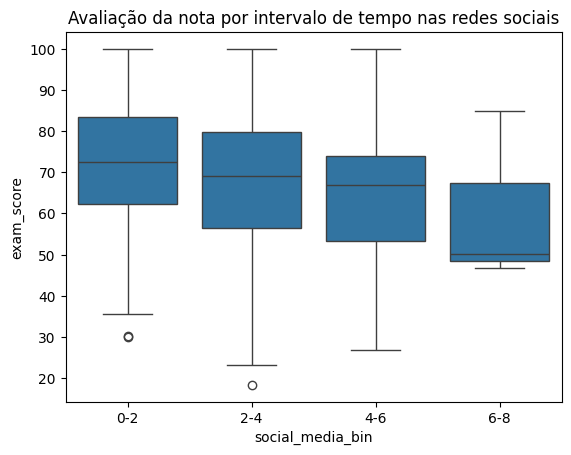

In [ ]:
# Avaliando notas médias
# por diferentes intervalos (bins) de períodos gastos em redes sociais
# [0,2] [2,4] [4,6] [6,8]

df["social_media_bin"] = pd.cut(
    df["social_media_hours"],
    bins=[0, 2, 4, 6, 8],
    labels=["0-2", "2-4", "4-6", "6-8"],
)

#plotar gráfico de caixa
sns.boxplot(x="social_media_bin", y="exam_score", data=df)

plt.title("Avaliação da nota por intervalo de tempo nas redes sociais")
plt.show()

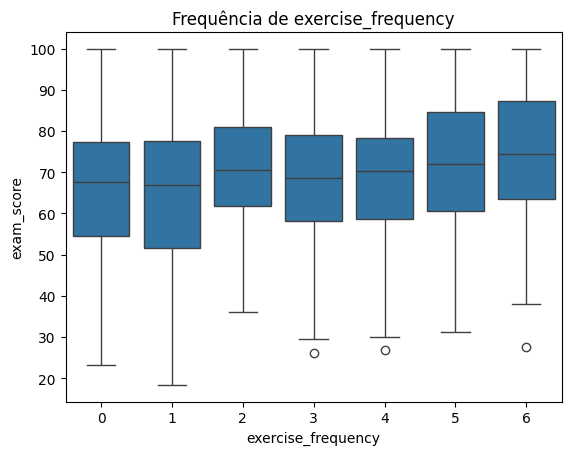

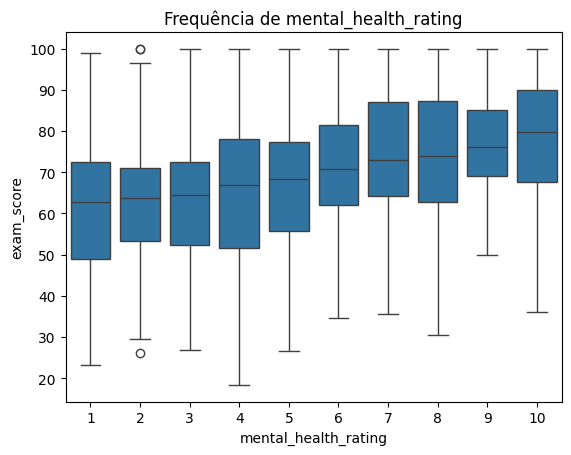

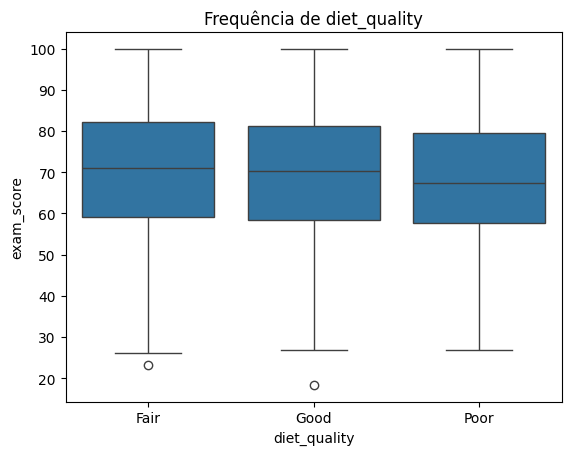

In [ ]:
# Frequência de exercícios físicos

for col in ["exercise_frequency", "mental_health_rating", "diet_quality"]:
    sns.boxplot(x=col, y="exam_score", data=df)
    plt.title(f"Frequência de {col}")
    plt.show()
#

In [ ]:
# Diferenca entre generos

df.groupby(["gender"])["exam_score"].agg(["mean", "std"])

,mean,std
gender,,
Female,69.741372,16.899351
Male,69.368344,17.150875
Other,70.647619,13.755890


In [ ]:
df["gender"].value_counts(normalize=True)

,proportion
gender,
Female,0.481
Male,0.477
Other,0.042
